# **CNNs PROFUNDAS E MODELOS PRÉ-TREINADOS**

Neste material, descreverei três redes neurais convolucionais (CNNs): a VGGNet, a GoogLeNet e a ResNet. A VGGNet tem 16 camadas, a GoogLeNet tem 22 e a ResNet-152 possui 152 camadas, mas, na prática, a maioria das pessoas usam a ResNet-50, com 50 camadas.

## **VGGNet**

A **VGGNet** foi proposta pelo Visual Geometry Group (VGG) da Universidade de Oxford. Um objetivo principal do artigo que descreveu a arquitetura foi estudar o efeito que a profundidade da rede tem na acurácia para CNNs. Para isso, eles criaram uma arquitetura na qual a profundidade da rede pode ser ajustada sem ter que ajustar outros parâmetros, como o tamanho do *kernel* e o *stride*. Eles usaram um tamanho de *kernel* fixo de 3x3 em todas as camadas convolucionais e um *stride* de 1. Usando o *stride* de 1, e assumindo que o *padding* apropriado foi usado, a largura e a altura das camadas convolucionais serão iguais. Isso possibilita tornar uma **VGGNet** arbitrariamente profunda sem sofrer com o problema de a largura e a altura das camadas mais profundas na rede se tornarem muito pequenas.

Como um dos objetivos é diminuir a altura e a largura para as outras camadas mais profundas, para que os neurônios identifique *features* de tamanho maior. A **VGGNet** resolve isso usando camadas de *max pooling* entre grupos de camadas convolucionais. Assim, um bloco de construção típico em uma **VGGNet** é um grupo de camadas convolucionais do mesmo tamanho, seguido por uma camada de *max pooling*.

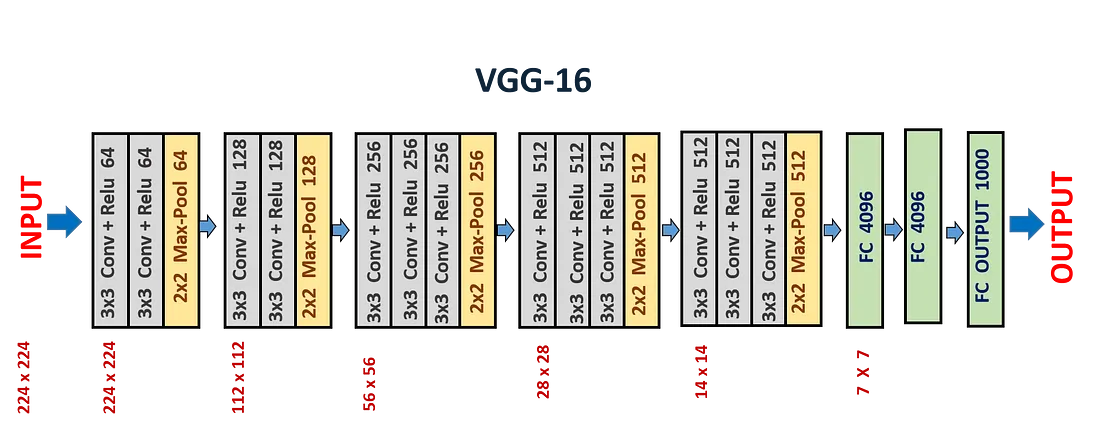 *Arquitetura da VGGNet com 16 camadas. Note que as camadas de convoluções sempre com mesma dimensão até que ocorra o max pool.*

Observando a imagem acima, nota-se a **VGGNet* começa com camadas convolucionais com 64 canais. Para cada camada de *max pooling*, a largura e a altura da próxima camada são reduzidas pela metade, e a camada convolucional subsequente dobra o número de canais. O número de canais é limitado a 512, após o qual a largura e a altura ainda são reduzidas pela metade para a próxima camada após o *pooling*, mas o número de canais é mantido constante. Os neurônios em todas as camadas convolucionais usam *ReLU* como função de ativação. 

Alguns resultados importantes do estudo da **VGGNet** foram que a acurácia da previsão aumentou com a profundidade do modelo até 16 camadas, mas depois se estabilizou em aproximadamente o mesmo nível para 19 camadas. *As camadas de pooling não foram incluídas nessas contagens porque não contêm pesos que podem ser treinados.*

A melhor configuração de classificação da **VGGNet** submetida ao desafio *ImageNet* 2014 resultou em uma taxa de erro top-5 de 7,32%. Isso pode ser comparado aos 15,3% da AlexNet. Essa taxa de erro top-5 é definida como a porcentagem de imagens de teste onde a categoria correta não está entre as cinco categorias que a rede prevê como as mais prováveis.

## **GoogLeNet**

A **GoogLeNet** é um bom exemplo de uma arquitetura de rede chamada *Inception*. Quando se vê ela pela primeira vez, ela parece muito mais complexa e irregular do que a *AlexNet e a VGGNet*, porque ela usa um bloco de construção chamado *módulo Inception*, que por si só é uma pequena rede. Este é um exemplo de uma arquitetura de **rede-dentro-de-rede (network-in-network)**, na qual uma pequena rede é usada como bloco de construção dentro de outra rede.

Os idealizadores dessa arquitetura rede-dentro-de-rede estavam estudando uma arquitetura disso para *CNN*, onde cada neurônio de uma camada convolucional seria substituído por uma pequena rede de múltiplos níveis, que servia para o mesmo papel do neurônio substituído. Assim como em uma camada convolucional tradicional, esta pequena rede de múltiplos níveis compartilharia pesos por toda a camada convolucional. O efeito é uma camada convolucional com a capacidade de classificar features que não são linearmente separáveis, o que não é possível para uma única camada convolucional tradicional. 

No entanto, o módulo **Inception** usado pela **GoogLeNet** tem um propósito diferente. Ele constrói uma camada convolucional que pode trabalhar, ao mesmo tempo, com **múltiplos tamanhos de campo receptivo**. Intuitivamente, isso pode ser útil porque raramente uma instância de um objeto específico (por exemplo, um gato) tem sempre o mesmo tamanho em todas as imagens.

O módulo **Inception** aborda a flexibilidade do tamanho do campo receptivo tendo múltiplas camadas convolucionais com diferentes tamanhos de *kernel* trabalhando lado a lado, cada uma produzindo um número de canais de saída. Contanto que a largura e a altura dos canais de saída sejam as mesmas, esses canais podem simplesmente ser concatenados para parecerem que vêm de uma única camada convolucional. Por exemplo, podemos ter 32 canais resultantes de uma camada convolucional com um *kernel* de 3x3 e 32 canais resultantes de uma camada com um *kernel* de 5x5, e no geral, o módulo *Inception* produziria 64 canais.

Como o custo computacional está diretamente ligado ao tamanho do *kernel* e ao número de canais na camada precedente, pois é isso que determina o número de pesos de uma camada convolucional (e o número de pesos influencia na quantidade de cálculos que o modelo irá fazer), o módulo **Inception** busca diminuir esse custo. Para isso, ele faz uso de convoluções de 1x1 antes de convoluções de 3x3 e 5x5, o que resulta em menos canais de entrada para esses *kernels* convolucionais. Da mesma forma, para evitar muitos canais de saída, uma convolução de 1x1 é aplicada à saída da operação de *max pooling*. Com essas convoluções de 1x1, temos controle total sobre o número de canais de entrada para os *kernels* de 3x3 e 5x5, bem como o número total de saídas do módulo **Inception** e, consequentemente, o número de pesos que precisam ser treinados.

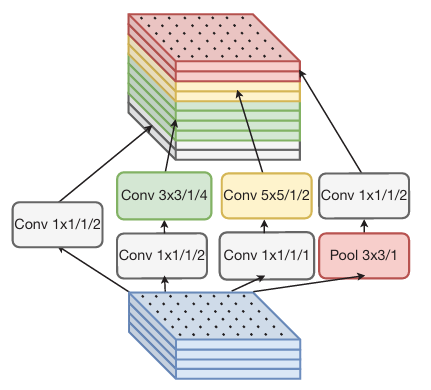 *Exemplo do módulo **Inception** do GoogLeNet*

*Nota-se que o stride escolhido é 1, pois o objetivo é ter as saídas com mesma altura e largura da entrada, para depois combiná-las. O uso do max pooling sem diminuir as dimensões da saída parece estranho, porém a justificativa usada foi simplesmente porque ele demonstrou ser útil em redes de ponta.*

Para permitir o treinamento de redes mais profundas, eles adicionaram **classificadores auxiliares** em diferentes pontos da rede. Um classificador auxiliar é similar ao que tipicamente colocaríamos no topo da rede, ou seja, uma camada totalmente conectada e uma camada *softmax* que calcula a probabilidade para as diferentes classes que estamos tentando prever. O objetivo desses classificadores auxiliares é poder injetar gradientes nesses pontos intermediários durante o treinamento e, assim, garantir que gradientes fortes se propaguem de volta para as primeiras camadas. Os classificadores auxiliares também incentivam as camadas iniciais da rede a serem treinadas para se comportarem de maneira muito semelhante a como se comportariam em uma rede mais rasa.

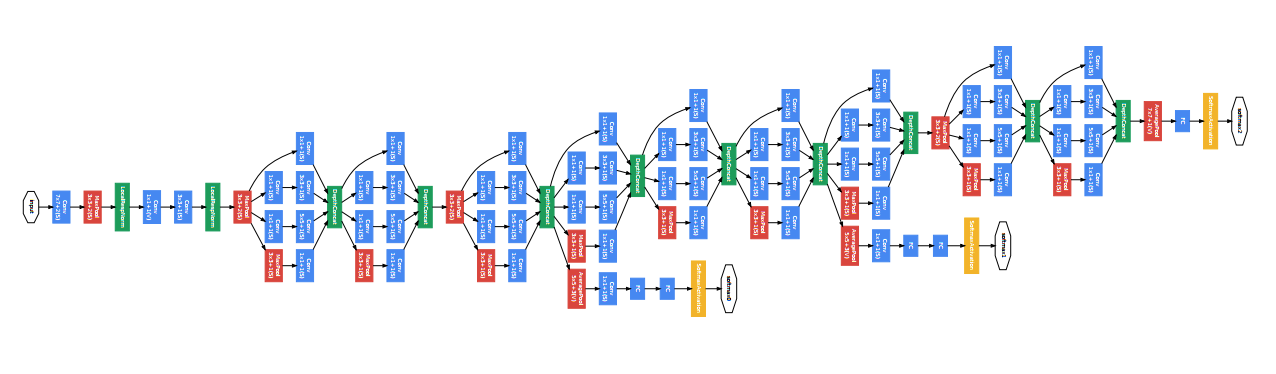 *Arquitetura da GoogLeNet*

No geral, a **GoogLeNet** demonstrou que é possível fazer uso de arquiteturas mais elaboradas para construir redes profundas de alto desempenho que têm um número relativamente pequeno de pesos. A rede de 22 camadas que foi submetida ao desafio de classificação *ImageNet* 2014 alcançou um erro top-5 de 6,67%, o que foi ligeiramente melhor que a VGGNet.

## **ResNet**